In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
pwd

'/content'

In [3]:
cd /content/drive/MyDrive/Colab/

/content/drive/MyDrive/Colab


In [4]:
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107720 sha256=a476aad28b0d9323a70802e82e38e248743564ce12e1d144c8f69728e51fe8f3
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [5]:
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score,confusion_matrix,accuracy_score
from sklearn.metrics import precision_recall_fscore_support,roc_curve,auc
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import *
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import eli5
from eli5.sklearn import PermutationImportance
from imblearn.combine import SMOTETomek
import plotly.graph_objects as go
from sklearn.feature_selection import SelectKBest, chi2

In [6]:
df = pd.read_csv('data/OSA_Data.csv',engine="python")

In [7]:
Ran_state = 80

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 92 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   OSA                                                 279 non-null    int64  
 1   Age                                                 279 non-null    int64  
 2   Sex                                                 279 non-null    int64  
 3   Current and past history of smoking                 279 non-null    int64  
 4   Amount of smoking                                   279 non-null    int64  
 5   Carbonated drink                                    279 non-null    float64
 6   Polysomnography                                     279 non-null    int64  
 7   Sleep disturbance                                   279 non-null    int64  
 8   Snoring Surgery                                     279 non-null    int64  
 9  

데이터 불러오기 끝.
데이터 전처리 시작

X(학습에 이용되는 변수값), Y(라벨, 타겟이 되는 값) 분리.

In [9]:
data_y = df['OSA']

data_x = df.drop('OSA',axis=1)

연속형 변수들 MinMaxScaler(변수 데이터를 최솟값이 0, 최댓값이 1의 범위로 표준화) 진행 *continuous한 변수들만.

In [10]:
DFS = data_x.iloc[:,[0,3,4,53,62,63,65,80]]
data_x = data_x.drop(DFS.columns,axis=1)

In [11]:
MM = MinMaxScaler()
DFSMM = MM.fit_transform(DFS)
DFS = pd.DataFrame(DFSMM,columns=DFS.columns)
data_x = pd.concat([data_x,DFS],axis=1)

학습용 데이터(Train)과 검증용 데이터(Test) 분리.

랜덤하게 선택되어 학습7, 검증3 비율로 분리한다.

In [12]:
train_x,test_x,train_y,test_y = train_test_split(data_x,data_y,test_size=0.3,random_state = Ran_state)

In [13]:
test_y.value_counts()

OSA
1    59
0    25
Name: count, dtype: int64

In [14]:
train_x,train_y = SMOTE(random_state=Ran_state).fit_resample(train_x,train_y)
train_x = pd.DataFrame(train_x,columns=data_x.columns)

In [15]:
LR = LogisticRegression(C=10,penalty='l2',random_state=Ran_state)
RF = RandomForestClassifier(max_depth=8,min_samples_split=25,n_estimators=100,random_state=Ran_state)
XGB = XGBClassifier(learning_rate=0.15,max_depth=12,n_estimators=200,random_state=Ran_state)
SVM = SVC(C=10,gamma=1,probability=True,random_state=Ran_state)

classlist = [LR,RF,XGB,SVM]

==================================================================

학습 및 예측

In [16]:
def create_curve(classlist,train_x,train_y,test_x,test_y):
    LR = classlist[0]
    RF = classlist[1]
    XGB = classlist[2]
    SVM = classlist[3]

    LR.fit(train_x,train_y)
    RF.fit(train_x,train_y)
    XGB.fit(train_x,train_y)
    SVM.fit(train_x,train_y)

    print('==========================================')
    print(train_x.columns)
    print(LR.coef_)
    print('==========================================')

    lr_proba = LR.predict_proba(test_x)[:,1]
    rf_proba = RF.predict_proba(test_x)[:,1]
    xgb_proba = XGB.predict_proba(test_x)[:,1]
    SVM_proba = SVM.decision_function(test_x)

    fpr_lr,tpr_lr,_=roc_curve(test_y,lr_proba)
    fpr_rf,tpr_rf,_=roc_curve(test_y,rf_proba)
    fpr_xgb,tpr_xgb,_=roc_curve(test_y,xgb_proba)
    fpr_svm,tpr_svm,_ = roc_curve(test_y,SVM_proba)

    auc_lr=auc(fpr_lr, tpr_lr)
    auc_xgb=auc(fpr_xgb, tpr_xgb)
    auc_rf=auc(fpr_rf, tpr_rf)
    auc_svm=auc(fpr_svm, tpr_svm)

    plt.plot(fpr_lr, tpr_lr, label="LR (AUC= %s)"%(round(auc_lr,3)))
    plt.plot(fpr_rf, tpr_rf, label="RF (AUC= %s)"%(round(auc_rf,3)))
    plt.plot(fpr_xgb, tpr_xgb, label="XGB (AUC= %s)"%(round(auc_xgb,3)))
    plt.plot(fpr_svm, tpr_svm, label="SVM (AUC= %s)"%(round(auc_svm,3)))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('1-specificity',fontsize=12)
    plt.ylabel('sensitivity',fontsize=15)
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right",fontsize=12)
    plt.show()

    Importance = pd.DataFrame(train_x.columns,columns=['feature'])
    suf = ('_LR','_RF','_XGB','_SVM')

    for i in range(4):
        PI = P_Importance(classlist[i],test_x,test_y).loc[:,['feature','weight']]
        Importance = pd.merge(Importance,PI,on='feature',suffixes=(suf[i-1],suf[i]))

    Importance['meanscore'] = Importance.apply(lambda x: np.mean(x[1:5]),1)
    ftr_top20 = Importance.sort_values(ascending=False,by='meanscore')[:]

    fig = go.Figure([go.Bar(x=ftr_top20.meanscore, y=ftr_top20.feature,orientation='h',marker={'color': ftr_top20.meanscore,'colorscale': 'Oryel'})])
    fig.update_layout(
    autosize=False,
    width=500,
    height=800,
    yaxis=dict(type='category',tickfont_size=18)

    )


    fig.show()

    return Importance

In [19]:
def P_Importance(model,test_x,test_y): #permutation importance 중요도 뽑기
    perm = PermutationImportance(model, scoring = "roc_auc", random_state = Ran_state).fit(test_x, test_y)
    ftr_importances = eli5.format_as_dataframe(eli5.explain_weights(perm,top=134, feature_names = test_x.columns.tolist()))
    ftr_top = ftr_importances.sort_values(ascending=False,by='feature')[:]
    return ftr_top

Index(['Sex', 'Current and past history of smoking', 'Polysomnography',
       'Sleep disturbance', 'Snoring Surgery', 'Positive pressure therapy',
       'Intraoral device', 'Hypertension', 'Angina pectoris',
       'Myocardial infarction', 'Arrhythmia', 'Heart surgery/procedure',
       'Stroke (stroke)', 'Diabetes', 'Chronic lung disease', 'Asthma',
       'Rhinitis', 'Sinusitis', 'Nasal bone fracture', 'Septum curvature',
       'Tonsil hypertrophy', 'Orthodontics', 'Menopause', 'Female hormone',
       'Mental illness', 'depression', 'psychiatric medication',
       'Neurostabilizer', 'Irritable bowel syndrom',
       'Gastro Esophageal Reflux', 'Prostate hypertrophy', 'ESS_Reading',
       'ESS_TV', 'ESS_Permit only public places', 'ESS_passenger',
       'ESS_Lying down', 'ESS_Conversation', 'ESS_After lunch',
       'ESS_traffic jam', 'Berlin_5-year weight change', 'Snoring from the BQ',
       'Loudness of snoring from the BQ', 'Berlin_How often',
       'Berlin_People around 

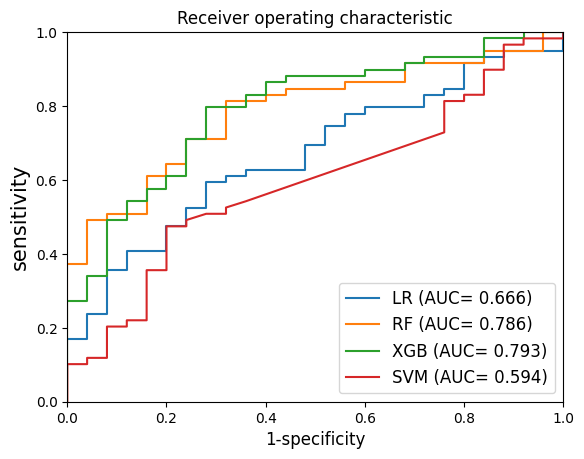

In [20]:
ftr_importances = create_curve(classlist,train_x,train_y,test_x,test_y)

In [21]:
ftr_importances

,feature,weight_LR,weight_RF,weight_XGB,weight_SVM,meanscore
0,Sex,-0.014915,0.001627,0.000000,-0.002237,-0.003881
1,Current and past history of smoking,-0.007458,0.008949,0.004881,-0.038576,-0.008051
2,Polysomnography,-0.000542,0.000136,0.000000,0.000068,-0.000085
3,Sleep disturbance,-0.000407,0.000000,0.000000,-0.002508,-0.000729
4,Snoring Surgery,-0.001220,-0.000271,0.000000,-0.004068,-0.001390
...,...,...,...,...,...,...
86,Berlin_Total score,-0.051390,-0.005559,-0.010305,-0.000746,-0.017000
87,FSS total score,0.022102,0.012339,0.047051,0.003729,0.021305
88,PSQI_Entrance time (minutes),0.003254,-0.001085,0.010983,0.000136,0.003322
89,PSQI_Actual remaining time (minutes),0.001492,0.004203,0.006373,-0.000881,0.002797


In [22]:
def roc_score(classlist,train_x,train_y,test_x,test_y):
    LR = classlist[0]
    RF = classlist[1]
    XGB = classlist[2]
    SVM = classlist[3]

    LR.fit(train_x,train_y)
    RF.fit(train_x,train_y)
    XGB.fit(train_x,train_y)
    SVM.fit(train_x,train_y)

    lr_proba = LR.predict_proba(test_x)[:,1]
    rf_proba = RF.predict_proba(test_x)[:,1]
    xgb_proba = XGB.predict_proba(test_x)[:,1]
    SVM_proba = SVM.decision_function(test_x)

    lr_score = roc_auc_score(test_y, lr_proba)
    rf_score = roc_auc_score(test_y, rf_proba)
    xgb_score = roc_auc_score(test_y, xgb_proba)
    SVM_score = roc_auc_score(test_y, SVM_proba)

    print(lr_score,rf_score,xgb_score,SVM_score)

    Importance = pd.DataFrame(train_x.columns,columns=['feature'])
    suf = ('_LR','_RF','_XGB','_SVM')

    for i in range(4):
        PI = P_Importance(classlist[i],test_x,test_y).loc[:,['feature','weight']]
        Importance = pd.merge(Importance,PI,on='feature',suffixes=(suf[i-1],suf[i]))

    Importance['meanscore'] = Importance.apply(lambda x: np.mean(x[1:5]),1)


    return np.max([lr_score,rf_score,xgb_score,SVM_score]),Importance

In [23]:
data_x.columns

Index(['Sex', 'Current and past history of smoking', 'Polysomnography',
       'Sleep disturbance', 'Snoring Surgery', 'Positive pressure therapy',
       'Intraoral device', 'Hypertension', 'Angina pectoris',
       'Myocardial infarction', 'Arrhythmia', 'Heart surgery/procedure',
       'Stroke (stroke)', 'Diabetes', 'Chronic lung disease', 'Asthma',
       'Rhinitis', 'Sinusitis', 'Nasal bone fracture', 'Septum curvature',
       'Tonsil hypertrophy', 'Orthodontics', 'Menopause', 'Female hormone',
       'Mental illness', 'depression', 'psychiatric medication',
       'Neurostabilizer', 'Irritable bowel syndrom',
       'Gastro Esophageal Reflux', 'Prostate hypertrophy', 'ESS_Reading',
       'ESS_TV', 'ESS_Permit only public places', 'ESS_passenger',
       'ESS_Lying down', 'ESS_Conversation', 'ESS_After lunch',
       'ESS_traffic jam', 'Berlin_5-year weight change', 'Snoring from the BQ',
       'Loudness of snoring from the BQ', 'Berlin_How often',
       'Berlin_People around 

Index(['Hypertension', 'Snoring from the BQ',
       'Loudness of snoring from the BQ', 'Falling asleep from the BQ',
       'Waist circumference', 'Subnasale to stomion', 'FSS total score'],
      dtype='object')
[[ 1.55499865 -0.20123078  0.50278302  0.36768476  0.9289038   0.78406384
  -2.02690227]]


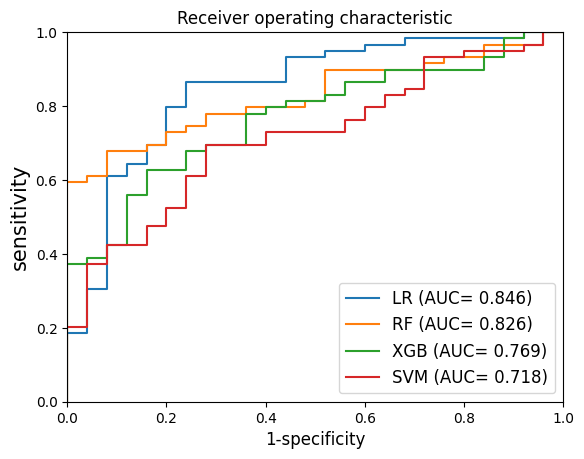

In [24]:
#초회 실행용
drop = data_x.drop(['Hypertension', 'Snoring from the BQ', 'Loudness of snoring from the BQ', 'Falling asleep from the BQ','FSS total score', 'Waist circumference', 'Subnasale to stomion'],axis=1)
new_data_x = data_x.drop(drop.columns,axis=1)
train_x,test_x,train_y,test_y = train_test_split(new_data_x,data_y,test_size=0.3,random_state = Ran_state)
ftr_importances = create_curve(classlist,train_x,train_y,test_x,test_y)